# Modeling Markets: Complete Project Analysis

## Discrete Hedging in Quantitative Finance

This notebook provides a comprehensive analysis of the discrete hedging project, covering:
1. **Preliminary Tests** - Validation of market model and theoretical properties
2. **Basic Delta Hedging** - Experiment 1: Rebalancing frequency analysis
3. **Transaction Costs** - Experiment 2: Cost-frequency trade-off
4. **Information-Aware Strategies** - Experiment 3: Adaptive hedging with information cards
5. **Agent Comparison** - All agents across different stopping times
6. **Risk Analytics** - Comprehensive risk metrics and error decomposition
7. **Visualizations** - Detailed plots and comparisons
8. **Inferences** - Key insights and conclusions

## 1. Setup and Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Import project modules
from market.substrate import MarketSubstrate
from events.time import TimeStoppingCondition
from events.engine import EventEngine
from events.cards import InformationCard
from events.information_generator import InformationGenerator
from simulation.log import EventLog
from simulation.runner import SimulationRunner
from agents.delta_hedging import DeltaHedgingAgent, AdaptiveDeltaHedgingAgent
from agents.information_aware_hedging import InformationAwareDeltaHedgingAgent
from execution.validator import ExecutionEngine
from execution.costs import ProportionalCostModel
from portfolio.tracker import PortfolioTracker
from options.payoff import EuropeanCallPayoff
from options.black_scholes import (
    black_scholes_call_price, 
    black_scholes_delta, 
    black_scholes_gamma
)

# Import visualization functions
from visualization.plots import (
    plot_single_path_detailed,
    plot_error_distribution_comparison,
    plot_convergence_analysis,
    plot_transaction_cost_impact,
    plot_risk_metrics_dashboard,
    set_plot_style
)

# Import analysis functions
from analysis.risk_metrics import (
    compute_var,
    compute_cvar,
    compute_shortfall_probability,
    generate_risk_report
)

from analysis.path_analysis import (
    identify_difficult_paths,
    extract_path_characteristics
)

print("✓ All imports successful")

✓ All imports successful


## 2. Project Overview and Parameters

In [28]:
# Standard option parameters
OPTION_PARAMS = {
    'S0': 100.0,
    'K': 100.0,
    'r': 0.05,
    'sigma': 0.2,
    'T': 1.0
}

# Stopping intervals to test
STOPPING_INTERVALS = [0.05, 0.1, 0.2]

# Number of Monte Carlo paths
N_PATHS = 1000

# Market simulation time step
DT_MARKET = 0.001

print("Project Parameters:")
print(f"  Initial Stock Price (S0): {OPTION_PARAMS['S0']}")
print(f"  Strike Price (K): {OPTION_PARAMS['K']}")
print(f"  Risk-free Rate (r): {OPTION_PARAMS['r']}")
print(f"  Volatility (σ): {OPTION_PARAMS['sigma']}")
print(f"  Time to Maturity (T): {OPTION_PARAMS['T']}")
print(f"  Stopping Intervals: {STOPPING_INTERVALS}")
print(f"  Number of Paths: {N_PATHS}")

# Compute Black-Scholes price
C_BS = black_scholes_call_price(
    OPTION_PARAMS['S0'], 
    OPTION_PARAMS['K'], 
    OPTION_PARAMS['r'], 
    OPTION_PARAMS['sigma'], 
    OPTION_PARAMS['T']
)
print(f"\n  Black-Scholes Price: {C_BS:.4f}")

Project Parameters:
  Initial Stock Price (S0): 100.0
  Strike Price (K): 100.0
  Risk-free Rate (r): 0.05
  Volatility (σ): 0.2
  Time to Maturity (T): 1.0
  Stopping Intervals: [0.05, 0.1, 0.2]
  Number of Paths: 1000

  Black-Scholes Price: 10.4506


## 3. Preliminary Tests

We run the test suite to validate our market model and theoretical properties.

### 3.1 Test: Log-Price Distribution

In [29]:
def test_logprice_distribution():
    """Test that log prices follow the correct distribution."""
    S0 = 100.0
    mu = 0.05
    sigma = 0.2
    T = 1.0
    N = 20000
    dt = 0.01

    log_prices = []
    for i in range(N):
        m = MarketSubstrate(0.0, [S0], mu, sigma, seed=i)
        for _ in range(int(T / dt)):
            m.advance_time(dt)
        log_prices.append(np.log(m.prices[0]))

    log_prices = np.array(log_prices)
    theoretical_mean = np.log(S0) + (mu - 0.5 * sigma**2) * T
    theoretical_var = sigma**2 * T

    empirical_mean = log_prices.mean()
    empirical_var = log_prices.var()
    
    print(f"Log-Price Distribution Test:")
    print(f"  Theoretical Mean: {theoretical_mean:.6f}")
    print(f"  Empirical Mean:   {empirical_mean:.6f}")
    print(f"  Difference:       {abs(empirical_mean - theoretical_mean):.6f}")
    print(f"  Theoretical Var:  {theoretical_var:.6f}")
    print(f"  Empirical Var:    {empirical_var:.6f}")
    print(f"  Difference:       {abs(empirical_var - theoretical_var):.6f}")
    
    assert abs(log_prices.mean() - theoretical_mean) < 0.05, "Mean test failed"
    assert abs(log_prices.var() - theoretical_var) < 0.05, "Variance test failed"
    print("  ✓ Test PASSED")
    
    return log_prices

log_prices = test_logprice_distribution()

Log-Price Distribution Test:
  Theoretical Mean: 4.635170
  Empirical Mean:   4.635097
  Difference:       0.000073
  Theoretical Var:  0.040000
  Empirical Var:    0.039889
  Difference:       0.000111
  ✓ Test PASSED


### 3.2 Test: Discounted Martingale Property

In [30]:
def test_discounted_martingale():
    """Test that discounted stock price is a martingale."""
    S0 = 100.0
    r = 0.05
    sigma = 0.2
    mu = r
    T = 1.0
    dt = 0.01
    N = 5000

    discounted_final = []
    for i in range(N):
        m = MarketSubstrate(0.0, [S0], mu, sigma, seed=i)
        for _ in range(int(T / dt)):
            m.advance_time(dt)
        discounted_final.append(np.exp(-r * T) * m.prices[0])

    discounted_final = np.array(discounted_final)
    
    print(f"Discounted Martingale Test:")
    print(f"  Expected Value (S0): {S0:.4f}")
    print(f"  Empirical Mean:      {discounted_final.mean():.4f}")
    print(f"  Difference:          {abs(discounted_final.mean() - S0):.4f}")
    
    assert abs(discounted_final.mean() - S0) < 1.0, "Martingale test failed"
    print("  ✓ Test PASSED")
    
    return discounted_final

discounted_prices = test_discounted_martingale()

Discounted Martingale Test:
  Expected Value (S0): 100.0000
  Empirical Mean:      99.9901
  Difference:          0.0099
  ✓ Test PASSED


### 3.3 Test: Path Continuity (No Jumps)

In [31]:
def test_no_jumps():
    """Test that price paths are continuous (no jumps)."""
    m = MarketSubstrate(0.0, [100.0], 0.05, 0.2, seed=42)
    dt = 0.001
    
    max_jump = 0.0
    prev_price = m.prices[0]
    
    for _ in range(1000):
        m.advance_time(dt)
        jump = abs(m.prices[0] - prev_price)
        max_jump = max(max_jump, jump)
        prev_price = m.prices[0]
    
    print(f"Path Continuity Test:")
    print(f"  Maximum jump size: {max_jump:.4f}")
    print(f"  Threshold:         10.0")
    
    assert max_jump < 10.0, "Jump test failed"
    print("  ✓ Test PASSED")
    
    return max_jump

max_jump = test_no_jumps()

Path Continuity Test:
  Maximum jump size: 1.9602
  Threshold:         10.0
  ✓ Test PASSED


### 3.4 Test: Variance Scaling

In [32]:
def test_variance_scaling():
    """Test that variance scales linearly with time."""
    def simulate(T, dt, seed):
        m = MarketSubstrate(0.0, [100.0], 0.05, 0.2, seed=seed)
        for _ in range(int(T / dt)):
            m.advance_time(dt)
        return np.log(m.prices[0])
    
    dt = 0.01
    N = 10000
    Ts = [1.0, 2.0, 4.0]
    vars_ = []

    for T in Ts:
        samples = [simulate(T, dt, i) for i in range(N)]
        vars_.append(np.var(samples))

    ratio_2 = vars_[1] / vars_[0]
    ratio_4 = vars_[2] / vars_[0]
    
    print(f"Variance Scaling Test:")
    print(f"  Var(T=1): {vars_[0]:.6f}")
    print(f"  Var(T=2): {vars_[1]:.6f}, Ratio: {ratio_2:.3f} (expected: 2.0)")
    print(f"  Var(T=4): {vars_[2]:.6f}, Ratio: {ratio_4:.3f} (expected: 4.0)")
    
    assert abs(ratio_2 - 2.0) < 0.2, "Variance scaling test failed"
    assert abs(ratio_4 - 4.0) < 0.4, "Variance scaling test failed"
    print("  ✓ Test PASSED")
    
    return vars_, ratio_2, ratio_4

variances, ratio_2, ratio_4 = test_variance_scaling()

Variance Scaling Test:
  Var(T=1): 0.039960
  Var(T=2): 0.080588, Ratio: 2.017 (expected: 2.0)
  Var(T=4): 0.158804, Ratio: 3.974 (expected: 4.0)
  ✓ Test PASSED


## 4. Helper Function: Run Single Path

In [33]:
def run_single_path(
    agent_class,
    stopping_interval,
    seed,
    use_information=False,
    transaction_cost_bps=0,
    return_history=False
):
    """
    Run a single Monte Carlo path with specified agent.
    
    Parameters
    ----------
    agent_class : class
        Agent class to use (DeltaHedgingAgent, AdaptiveDeltaHedgingAgent, etc.)
    stopping_interval : float
        Time between rebalancing
    seed : int
        Random seed
    use_information : bool
        Whether to use information generator
    transaction_cost_bps : float
        Transaction cost in basis points
    return_history : bool
        Whether to return full history
    
    Returns
    -------
    dict with replication_error, trade_count, total_costs, and optionally history
    """
    S0 = OPTION_PARAMS['S0']
    K = OPTION_PARAMS['K']
    r = OPTION_PARAMS['r']
    sigma = OPTION_PARAMS['sigma']
    T = OPTION_PARAMS['T']
    
    # Compute Black-Scholes price and initial delta
    C_BS = black_scholes_call_price(S0, K, r, sigma, T)
    delta_0 = black_scholes_delta(S0, K, r, sigma, T, t=0.0)
    
    # Market
    market = MarketSubstrate(
        initial_time=0.0,
        initial_prices=[S0],
        mu=r,
        sigma=sigma,
        seed=seed
    )

    # Agent
    option_params = {'K': K, 'r': r, 'sigma': sigma, 'T': T}
    
    if agent_class == InformationAwareDeltaHedgingAgent:
        agent = agent_class(
            capital=C_BS,
            option_params=option_params,
            asset_index=0,
            base_tolerance=0.001,
            volatility_adaptation=True,
            gamma_adaptation=True,
            cost_optimization=True
        )
    elif agent_class == AdaptiveDeltaHedgingAgent:
        agent = agent_class(
            capital=C_BS,
            option_params=option_params,
            asset_index=0,
            base_tolerance=0.001
        )
    else:  # DeltaHedgingAgent
        agent = agent_class(
            capital=C_BS,
            option_params=option_params,
            asset_index=0,
            rebalance_tolerance=0.001
        )
    
    # Set initial position
    initial_cost = delta_0 * S0
    agent.capital -= initial_cost
    agent.positions[0] = delta_0

    # Portfolio tracker
    tracker = PortfolioTracker(agent)

    # Stopping times
    stopping_events = []
    t = stopping_interval
    while t <= T:
        stopping_events.append(
            (TimeStoppingCondition(trigger_time=t),
             InformationCard(name="rebalancing", payload={}))
        )
        t += stopping_interval

    # Information generator (if needed)
    information_generator = None
    if use_information:
        information_generator = InformationGenerator(
            option_params=option_params,
            lookback_window=10,
            gamma_threshold=0.015
        )

    # Event engine
    engine = EventEngine(market, stopping_events, information_generator)

    # Execution with transaction costs
    cost_model = None
    if transaction_cost_bps > 0:
        cost_model = ProportionalCostModel(rate_bps=transaction_cost_bps)
    
    execution_engine = ExecutionEngine(cost_model=cost_model)

    # Simulation runner
    runner = SimulationRunner(
        market=market,
        event_engine=engine,
        event_log=EventLog(),
        agents=[agent],
        execution_engine=execution_engine,
        portfolio_trackers=[tracker]
    )

    # Run simulation
    runner.run(dt=DT_MARKET, max_events=len(stopping_events))

    # Terminal payoff
    payoff = EuropeanCallPayoff(K)
    ST = market.get_state()["prices"][0]
    option_payoff = payoff(ST)

    # Terminal portfolio value
    VT = tracker.history[-1]["value"]
    
    # Results
    result = {
        'replication_error': VT - option_payoff,
        'trade_count': agent.trade_count,
        'total_costs': agent.total_transaction_costs,
        'final_value': VT,
        'option_payoff': option_payoff
    }
    
    if return_history:
        # Extract market history from tracker's recorded portfolio history
        # The tracker records market prices, so we use that
        market_history = [
            {'time': entry.get('time', i * DT_MARKET), 'price': entry.get('market_price', S0)}
            for i, entry in enumerate(tracker.history)
        ]
        result['market_history'] = market_history
        result['portfolio_history'] = tracker.history
    
    if use_information and hasattr(agent, 'get_adaptation_summary'):
        result['adaptation_summary'] = agent.get_adaptation_summary()
    
    return result

## 5. Experiment 1: Basic Delta Hedging (All Agents, 3 Stopping Times)

In [34]:
print("="*70)
print("EXPERIMENT 1: Delta Hedging Performance Comparison")
print("="*70)
print(f"Testing {len(STOPPING_INTERVALS)} stopping intervals with {N_PATHS} paths each")
print(f"Agents: DeltaHedgingAgent, AdaptiveDeltaHedgingAgent, InformationAwareDeltaHedgingAgent")
print("="*70 + "\n")

# Store results
experiment1_results = {}

agents_to_test = [
    ('DeltaHedging', DeltaHedgingAgent),
    ('AdaptiveDeltaHedging', AdaptiveDeltaHedgingAgent),
    ('InformationAware', InformationAwareDeltaHedgingAgent)
]

for agent_name, agent_class in agents_to_test:
    print(f"\n{'='*70}")
    print(f"Agent: {agent_name}")
    print(f"{'='*70}")
    
    experiment1_results[agent_name] = {}
    
    for interval in STOPPING_INTERVALS:
        print(f"\nStopping Interval Δt = {interval:.3f}")
        
        errors = []
        costs = []
        trades = []
        
        use_info = (agent_class == InformationAwareDeltaHedgingAgent)
        
        for i in range(N_PATHS):
            result = run_single_path(
                agent_class=agent_class,
                stopping_interval=interval,
                seed=i,
                use_information=use_info
            )
            errors.append(result['replication_error'])
            costs.append(result['total_costs'])
            trades.append(result['trade_count'])
        
        errors = np.array(errors)
        costs = np.array(costs)
        trades = np.array(trades)
        
        experiment1_results[agent_name][interval] = {
            'errors': errors,
            'costs': costs,
            'trades': trades
        }
        
        # Print statistics
        print(f"  Mean error:        {np.mean(errors):>8.4f}")
        print(f"  Std error:         {np.std(errors):>8.4f}")
        print(f"  Median error:      {np.median(errors):>8.4f}")
        print(f"  P(loss):           {np.mean(errors < 0):>8.3f}")
        print(f"  Mean trade count:  {np.mean(trades):>8.1f}")

print("\n" + "="*70)
print("Experiment 1 Complete")
print("="*70)

EXPERIMENT 1: Delta Hedging Performance Comparison
Testing 3 stopping intervals with 1000 paths each
Agents: DeltaHedgingAgent, AdaptiveDeltaHedgingAgent, InformationAwareDeltaHedgingAgent


Agent: DeltaHedging

Stopping Interval Δt = 0.050
  Mean error:          3.1342
  Std error:           5.7347
  Median error:        4.4791
  P(loss):              0.231
  Mean trade count:       0.2

Stopping Interval Δt = 0.100
  Mean error:          2.9837
  Std error:           5.7605
  Median error:        4.0792
  P(loss):              0.240
  Mean trade count:       0.4

Stopping Interval Δt = 0.200
  Mean error:          2.9589
  Std error:           5.8211
  Median error:        4.2476
  P(loss):              0.263
  Mean trade count:       0.3

Agent: AdaptiveDeltaHedging

Stopping Interval Δt = 0.050
  Mean error:          3.1342
  Std error:           5.7347
  Median error:        4.4791
  P(loss):              0.231
  Mean trade count:       0.2

Stopping Interval Δt = 0.100
  Mean err

## 6. Experiment 2: Transaction Costs Analysis

In [35]:
print("="*70)
print("EXPERIMENT 2: Transaction Costs Impact")
print("="*70)

cost_rates_bps = [0, 5, 10, 20, 50]
experiment2_results = {}

for cost_bps in cost_rates_bps:
    print(f"\n{'='*70}")
    print(f"Transaction Cost Rate: {cost_bps} bps ({cost_bps/100:.2f}%)")
    print(f"{'='*70}")
    
    experiment2_results[cost_bps] = {}
    
    for interval in STOPPING_INTERVALS:
        print(f"\nStopping Interval Δt = {interval:.3f}")
        
        errors = []
        costs = []
        trades = []
        
        for i in range(N_PATHS):
            result = run_single_path(
                agent_class=DeltaHedgingAgent,
                stopping_interval=interval,
                seed=i,
                transaction_cost_bps=cost_bps
            )
            errors.append(result['replication_error'])
            costs.append(result['total_costs'])
            trades.append(result['trade_count'])
        
        errors = np.array(errors)
        costs = np.array(costs)
        trades = np.array(trades)
        
        experiment2_results[cost_bps][interval] = {
            'errors': errors,
            'costs': costs,
            'trades': trades
        }
        
        mean_error = np.mean(errors)
        mean_cost = np.mean(costs)
        effective_cost = mean_error + mean_cost
        
        print(f"  Mean error:           {mean_error:>8.4f}")
        print(f"  Mean transaction cost: {mean_cost:>8.4f}")
        print(f"  Effective cost:       {effective_cost:>8.4f}")
        print(f"  Mean trade count:     {np.mean(trades):>8.1f}")

print("\n" + "="*70)
print("Experiment 2 Complete")
print("="*70)

EXPERIMENT 2: Transaction Costs Impact

Transaction Cost Rate: 0 bps (0.00%)

Stopping Interval Δt = 0.050
  Mean error:             3.1342
  Mean transaction cost:   0.0000
  Effective cost:         3.1342
  Mean trade count:          0.2

Stopping Interval Δt = 0.100
  Mean error:             2.9837
  Mean transaction cost:   0.0000
  Effective cost:         2.9837
  Mean trade count:          0.4

Stopping Interval Δt = 0.200
  Mean error:             2.9589
  Mean transaction cost:   0.0000
  Effective cost:         2.9589
  Mean trade count:          0.3

Transaction Cost Rate: 5 bps (0.05%)

Stopping Interval Δt = 0.050
  Mean error:             3.1306
  Mean transaction cost:   0.0052
  Effective cost:         3.1357
  Mean trade count:          0.2

Stopping Interval Δt = 0.100
  Mean error:             2.9770
  Mean transaction cost:   0.0092
  Effective cost:         2.9862
  Mean trade count:          0.4

Stopping Interval Δt = 0.200
  Mean error:             2.9504
  Mean 

## 7. Visualizations

### 7.1 Error Distribution Comparison (All Agents)

<Figure size 1400x500 with 0 Axes>

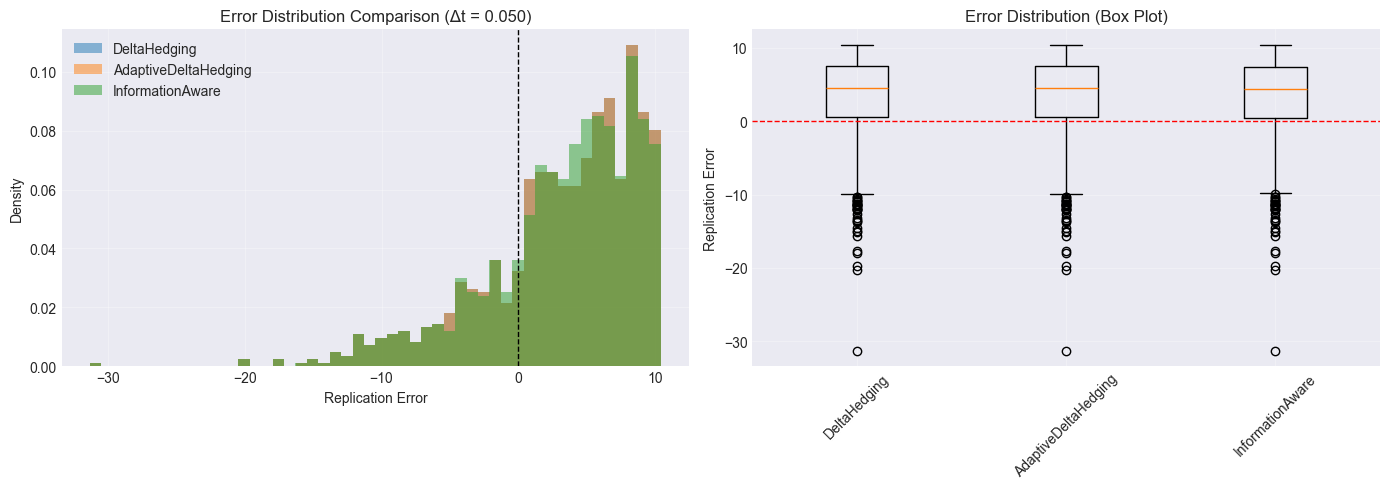

<Figure size 1400x500 with 0 Axes>

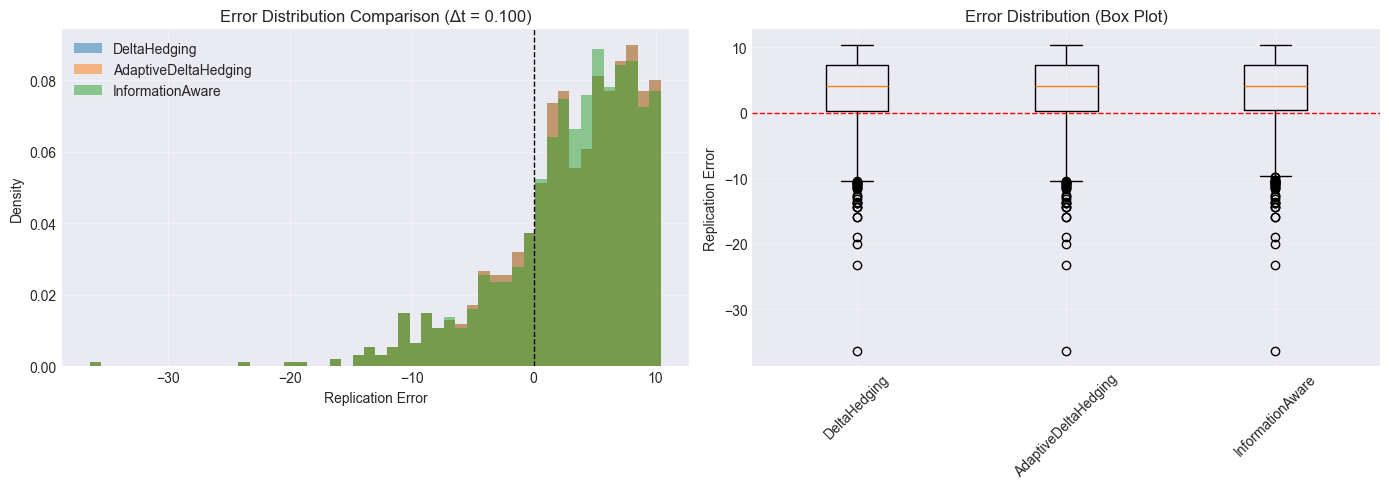

<Figure size 1400x500 with 0 Axes>

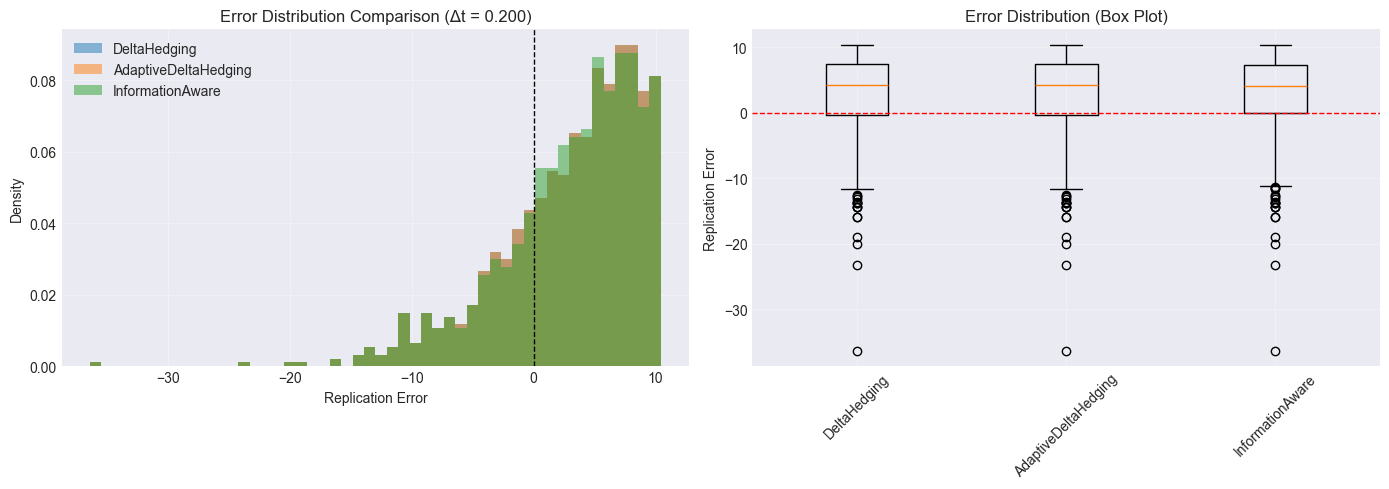

In [36]:
# Compare error distributions for all agents at each stopping interval
for interval in STOPPING_INTERVALS:
    fig = plt.figure(figsize=(14, 5))
    
    # Prepare data
    results_dict = {}
    for agent_name in experiment1_results.keys():
        results_dict[agent_name] = experiment1_results[agent_name][interval]['errors']
    
    # Plot
    fig = plot_error_distribution_comparison(
        results_dict, 
        title=f"Error Distribution Comparison (Δt = {interval:.3f})"
    )
    plt.tight_layout()
    plt.show()

### 7.2 Convergence Analysis

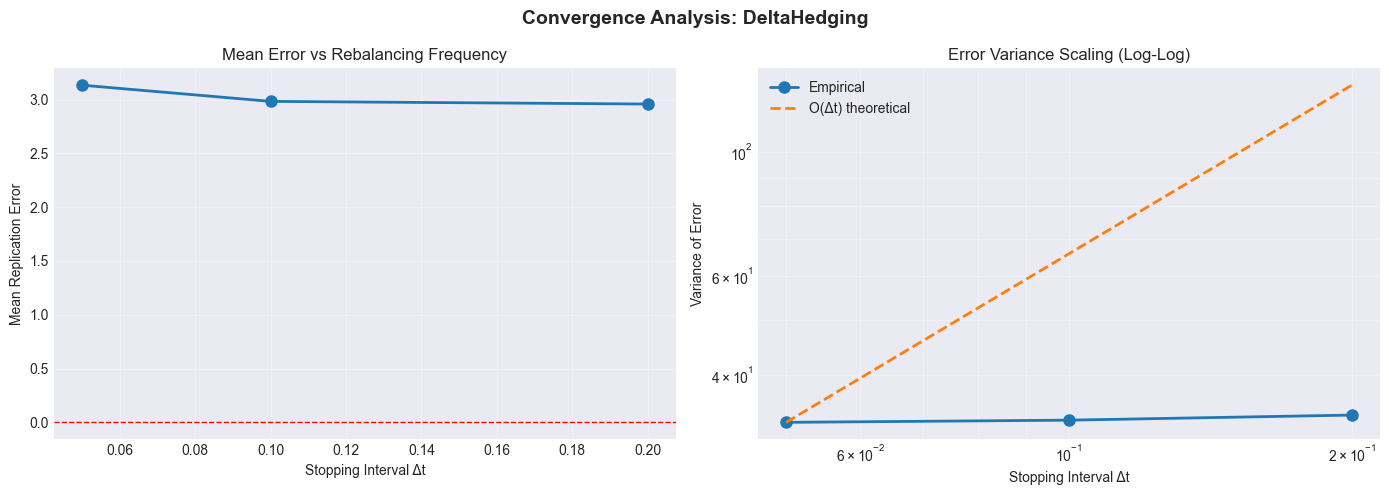

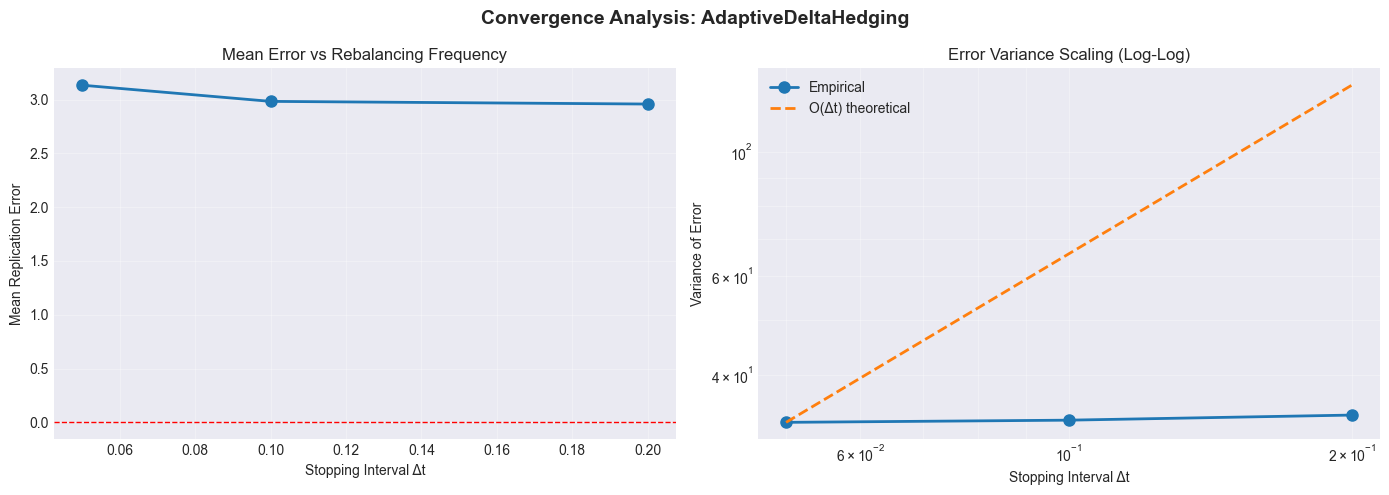

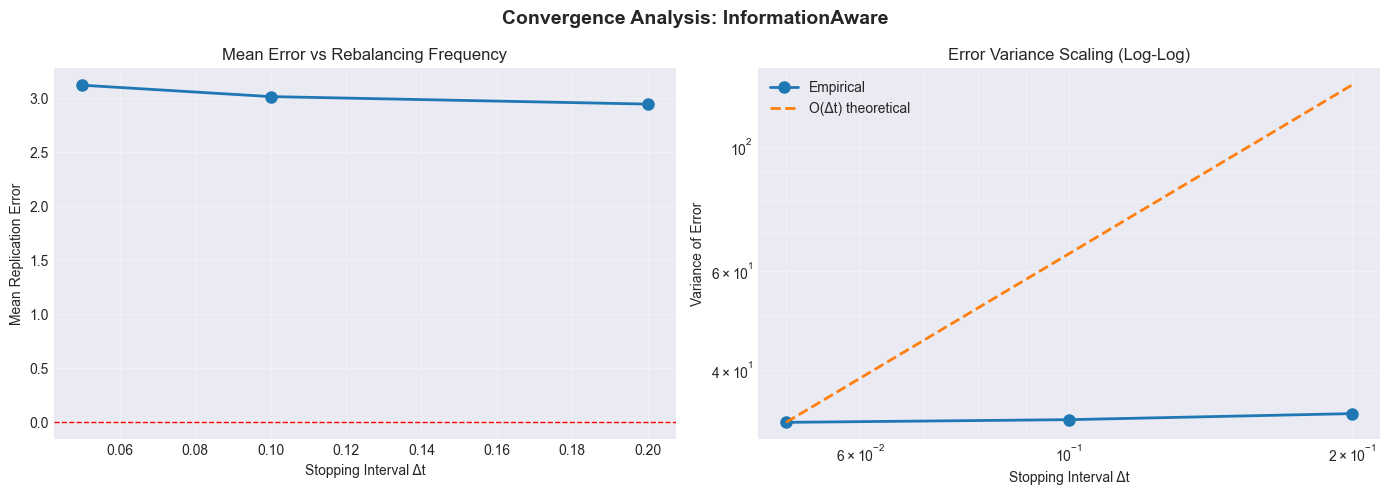

In [37]:
# Convergence analysis for each agent
for agent_name in experiment1_results.keys():
    errors_dict = {
        'mean': [np.mean(experiment1_results[agent_name][interval]['errors']) 
                 for interval in STOPPING_INTERVALS],
        'std': [np.std(experiment1_results[agent_name][interval]['errors']) 
                for interval in STOPPING_INTERVALS],
        'var': [np.var(experiment1_results[agent_name][interval]['errors']) 
                for interval in STOPPING_INTERVALS]
    }
    
    fig = plot_convergence_analysis(STOPPING_INTERVALS, errors_dict)
    plt.suptitle(f"Convergence Analysis: {agent_name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 7.3 Transaction Cost Impact

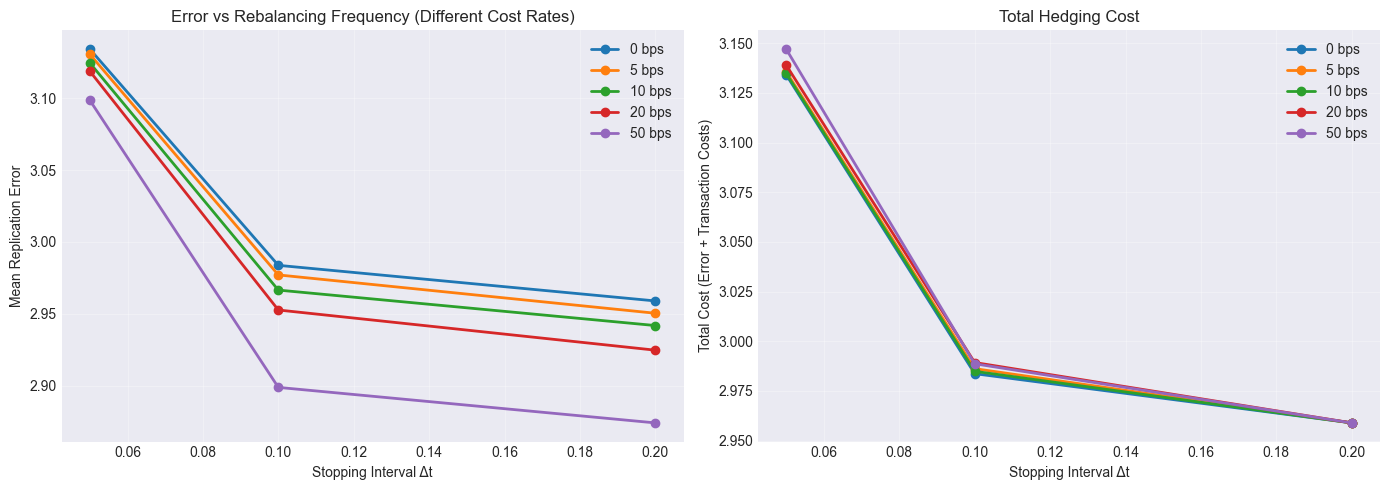

In [38]:
# Prepare transaction cost results for plotting
cost_results = {}
for cost_bps in cost_rates_bps:
    cost_results[cost_bps] = {}
    for interval in STOPPING_INTERVALS:
        errors = experiment2_results[cost_bps][interval]['errors']
        costs = experiment2_results[cost_bps][interval]['costs']
        cost_results[cost_bps][interval] = {
            'mean_error': np.mean(errors),
            'mean_cost': np.mean(costs)
        }

fig = plot_transaction_cost_impact(cost_rates_bps, STOPPING_INTERVALS, cost_results)
plt.tight_layout()
plt.show()

### 7.4 Detailed Single Path Analysis

Running detailed single path analysis...

Path Summary:
  Total portfolio value at T=1.0: $1.4543
  Option payoff at expiry: $0.0000
  Replication error: $1.4543
  Number of trades: 1
  Total transaction costs: $0.0000

Market path steps recorded: 10
Portfolio tracking steps: 10

Generating visualization...


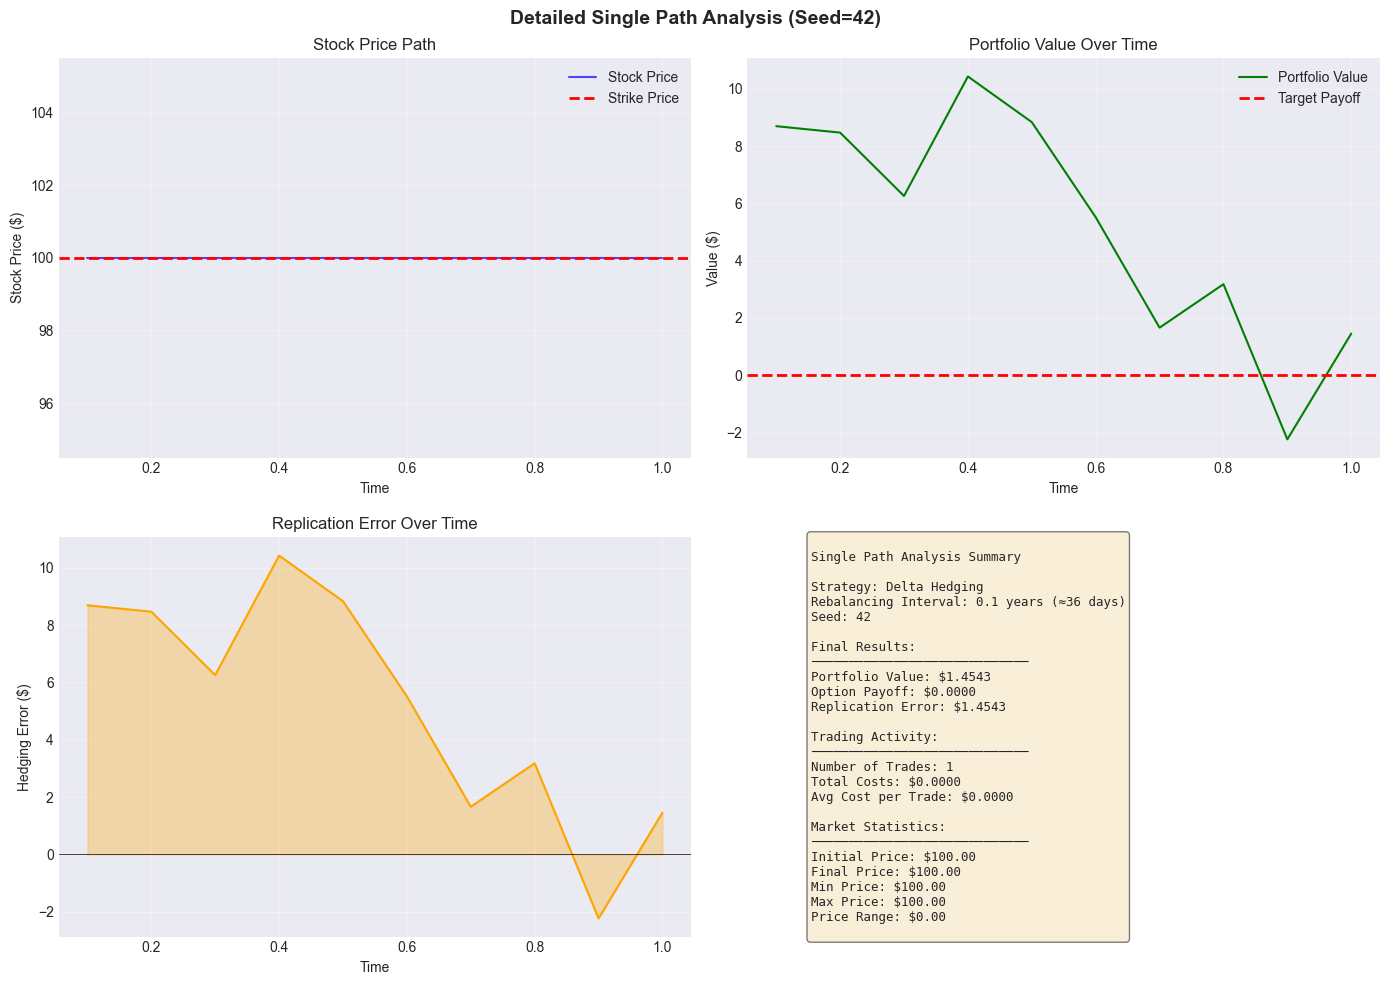


✓ Visualization complete


In [39]:
# Run a single detailed path for visualization
print("Running detailed single path analysis...")

result = run_single_path(
    agent_class=DeltaHedgingAgent,
    stopping_interval=0.1,
    seed=42,
    return_history=True
)

# Extract market and portfolio history
market_history = result['market_history']
portfolio_history = result['portfolio_history']

print(f"\nPath Summary:")
print(f"  Total portfolio value at T=1.0: ${result['final_value']:.4f}")
print(f"  Option payoff at expiry: ${result['option_payoff']:.4f}")
print(f"  Replication error: ${result['replication_error']:.4f}")
print(f"  Number of trades: {result['trade_count']}")
print(f"  Total transaction costs: ${result['total_costs']:.4f}")
print(f"\nMarket path steps recorded: {len(market_history)}")
print(f"Portfolio tracking steps: {len(portfolio_history)}")

# Create visualization
print("\nGenerating visualization...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Market price path
times = [h['time'] for h in market_history]
prices = [h['price'] for h in market_history]
ax1 = axes[0, 0]
ax1.plot(times, prices, 'b-', linewidth=1.5, alpha=0.7, label='Stock Price')
ax1.axhline(OPTION_PARAMS['K'], color='r', linestyle='--', linewidth=2, label='Strike Price')
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price ($)')
ax1.set_title('Stock Price Path')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Portfolio value
portfolio_times = [h.get('time', i * DT_MARKET) for i, h in enumerate(portfolio_history)]
portfolio_values = [h['value'] for h in portfolio_history]
ax2 = axes[0, 1]
ax2.plot(portfolio_times, portfolio_values, 'g-', linewidth=1.5, label='Portfolio Value')
ax2.axhline(result['option_payoff'], color='r', linestyle='--', linewidth=2, label='Target Payoff')
ax2.set_xlabel('Time')
ax2.set_ylabel('Value ($)')
ax2.set_title('Portfolio Value Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Error over time
errors_over_time = [v - (prices[min(i, len(prices)-1)] - OPTION_PARAMS['K'])*1 
                    for i, v in enumerate(portfolio_values)]
ax3 = axes[1, 0]
ax3.plot(portfolio_times, errors_over_time, 'orange', linewidth=1.5)
ax3.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax3.fill_between(portfolio_times, 0, errors_over_time, alpha=0.3, color='orange')
ax3.set_xlabel('Time')
ax3.set_ylabel('Hedging Error ($)')
ax3.set_title('Replication Error Over Time')
ax3.grid(True, alpha=0.3)

# Plot 4: Statistics
ax4 = axes[1, 1]
ax4.axis('off')
stats_text = f"""
Single Path Analysis Summary

Strategy: Delta Hedging
Rebalancing Interval: 0.1 years (≈36 days)
Seed: 42

Final Results:
─────────────────────────────
Portfolio Value: ${result['final_value']:.4f}
Option Payoff: ${result['option_payoff']:.4f}
Replication Error: ${result['replication_error']:.4f}

Trading Activity:
─────────────────────────────
Number of Trades: {result['trade_count']}
Total Costs: ${result['total_costs']:.4f}
Avg Cost per Trade: ${result['total_costs']/max(1, result['trade_count']):.4f}

Market Statistics:
─────────────────────────────
Initial Price: ${prices[0]:.2f}
Final Price: ${prices[-1]:.2f}
Min Price: ${min(prices):.2f}
Max Price: ${max(prices):.2f}
Price Range: ${max(prices) - min(prices):.2f}
"""
ax4.text(0.1, 0.5, stats_text, transform=ax4.transAxes, fontfamily='monospace',
         fontsize=9, verticalalignment='center', bbox=dict(boxstyle='round', 
         facecolor='wheat', alpha=0.5))

plt.suptitle('Detailed Single Path Analysis (Seed=42)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete")

## 8. Risk Analytics

### 8.1 Risk Metrics Dashboard

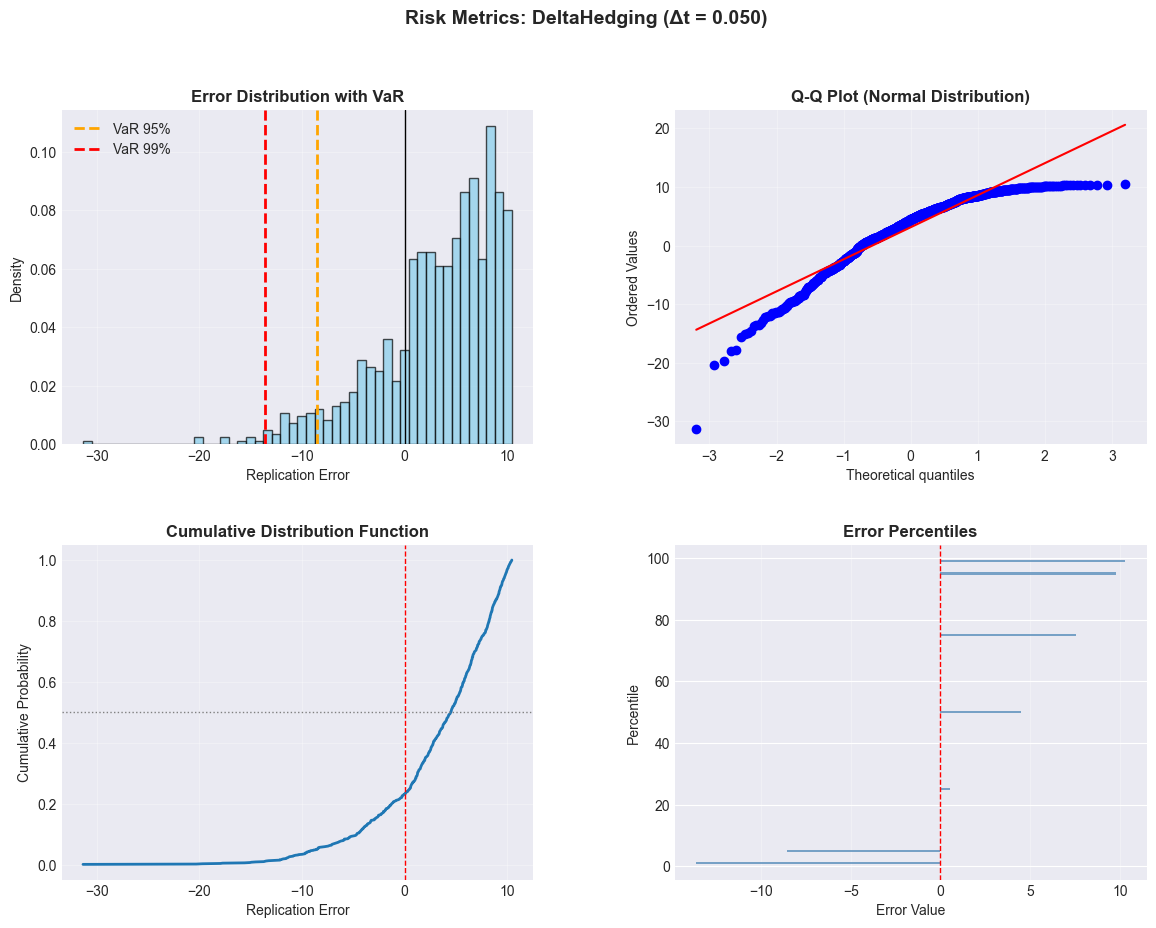


Risk Report: DeltaHedging (Δt = 0.050)
----------------------------------------------------------------------
  mean_error                    :     3.1342
  median_error                  :     4.4791
  std_error                     :     5.7347
  min_error                     :   -31.3333
  max_error                     :    10.4395
  percentile_1                  :   -13.6104
  percentile_5                  :    -8.5630
  percentile_25                 :     0.5441
  percentile_75                 :     7.5739
  percentile_95                 :     9.7933
  percentile_99                 :    10.2876
  var_90                        :    -4.6471
  var_95                        :    -8.5630
  var_99                        :   -13.6104
  cvar_90                       :    -9.2991
  cvar_95                       :   -12.1503
  cvar_99                       :   -18.0849
  prob_loss                     :     0.2310
  prob_loss_1pct                :     0.2310
  prob_loss_5pct                : 

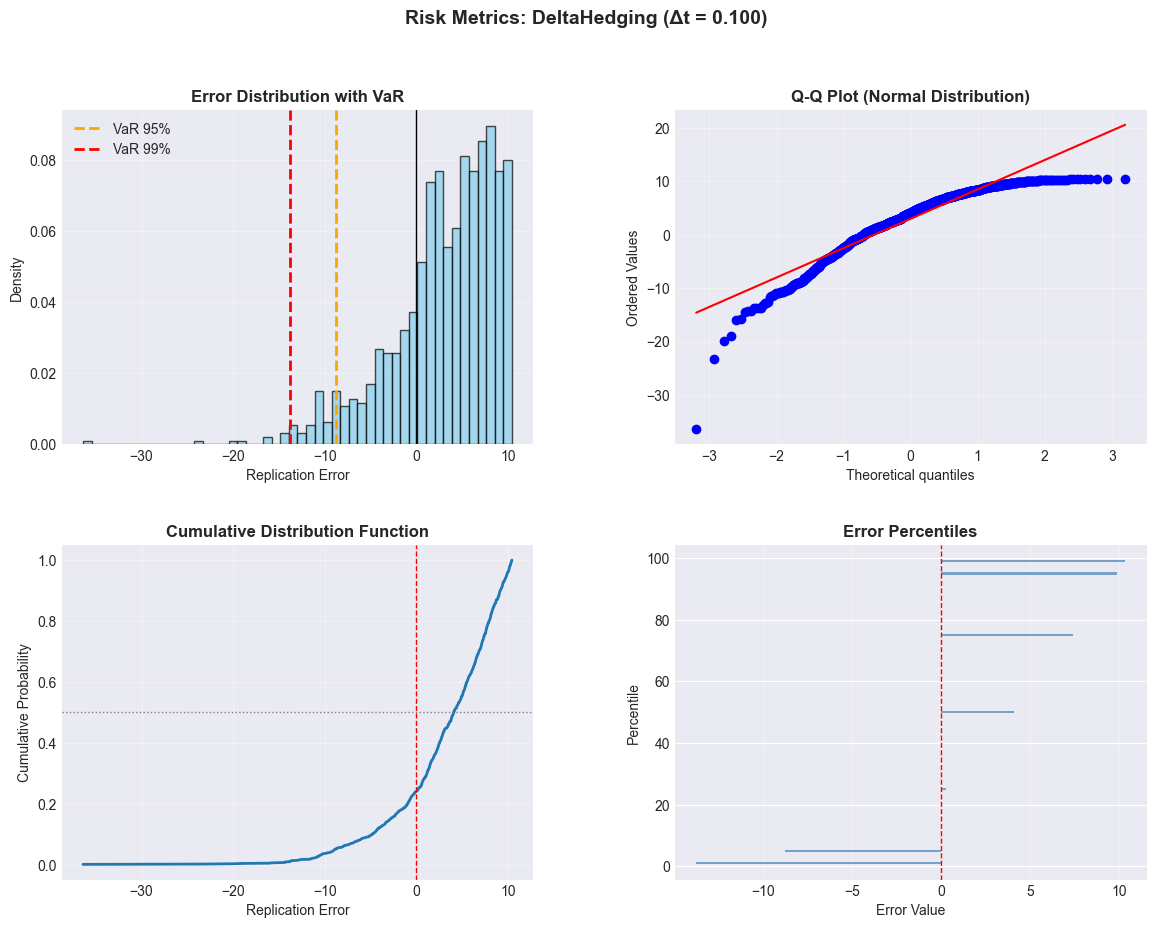


Risk Report: DeltaHedging (Δt = 0.100)
----------------------------------------------------------------------
  mean_error                    :     2.9837
  median_error                  :     4.0792
  std_error                     :     5.7605
  min_error                     :   -36.3930
  max_error                     :    10.4164
  percentile_1                  :   -13.7708
  percentile_5                  :    -8.8133
  percentile_25                 :     0.2734
  percentile_75                 :     7.3909
  percentile_95                 :     9.8574
  percentile_99                 :    10.3176
  var_90                        :    -4.7572
  var_95                        :    -8.8133
  var_99                        :   -13.7708
  cvar_90                       :    -9.5013
  cvar_95                       :   -12.3014
  cvar_99                       :   -18.7377
  prob_loss                     :     0.2400
  prob_loss_1pct                :     0.2400
  prob_loss_5pct                : 

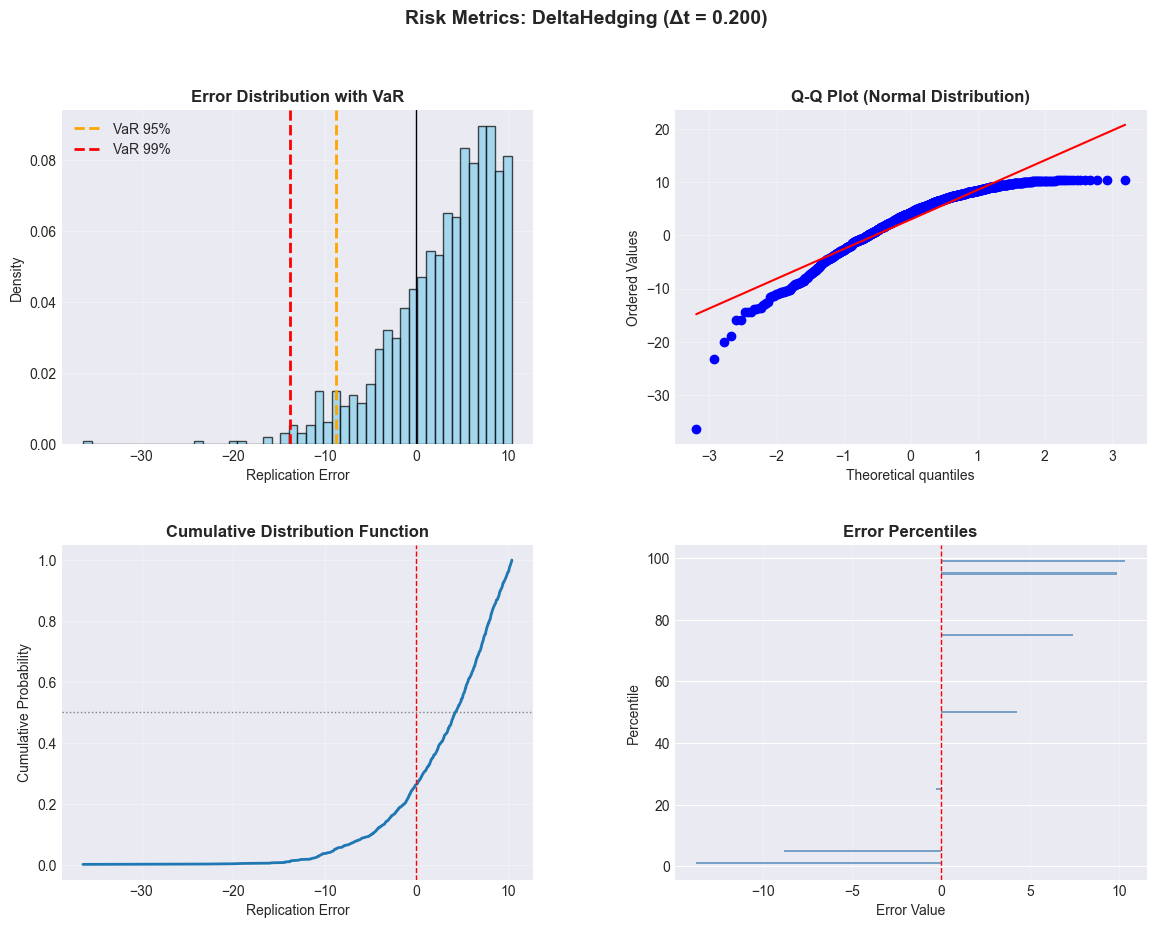


Risk Report: DeltaHedging (Δt = 0.200)
----------------------------------------------------------------------
  mean_error                    :     2.9589
  median_error                  :     4.2476
  std_error                     :     5.8211
  min_error                     :   -36.3930
  max_error                     :    10.4168
  percentile_1                  :   -13.7708
  percentile_5                  :    -8.8133
  percentile_25                 :    -0.3264
  percentile_75                 :     7.4059
  percentile_95                 :     9.8638
  percentile_99                 :    10.3207
  var_90                        :    -4.7697
  var_95                        :    -8.8133
  var_99                        :   -13.7708
  cvar_90                       :    -9.5245
  cvar_95                       :   -12.3014
  cvar_99                       :   -18.7377
  prob_loss                     :     0.2630
  prob_loss_1pct                :     0.2630
  prob_loss_5pct                : 

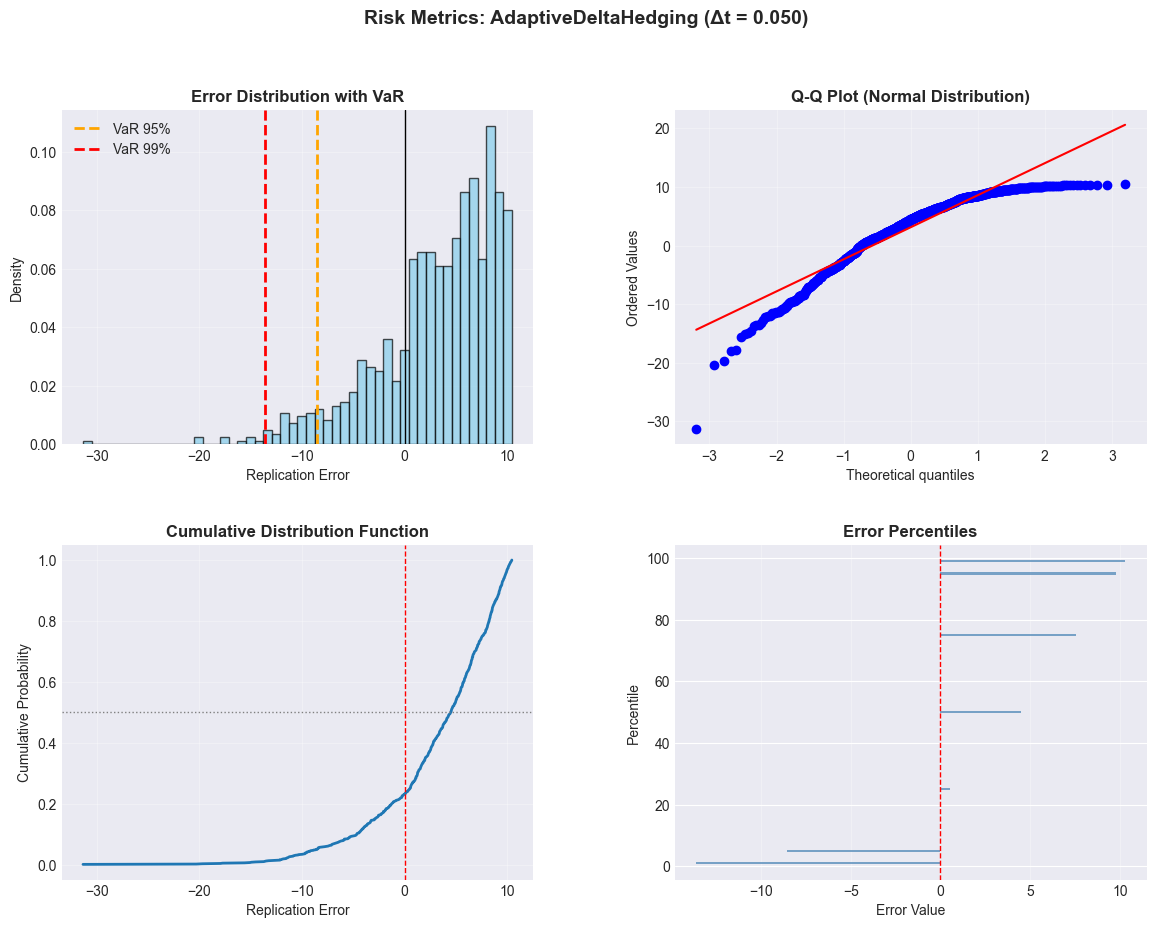


Risk Report: AdaptiveDeltaHedging (Δt = 0.050)
----------------------------------------------------------------------
  mean_error                    :     3.1342
  median_error                  :     4.4791
  std_error                     :     5.7347
  min_error                     :   -31.3333
  max_error                     :    10.4395
  percentile_1                  :   -13.6104
  percentile_5                  :    -8.5630
  percentile_25                 :     0.5441
  percentile_75                 :     7.5739
  percentile_95                 :     9.7933
  percentile_99                 :    10.2876
  var_90                        :    -4.6471
  var_95                        :    -8.5630
  var_99                        :   -13.6104
  cvar_90                       :    -9.2991
  cvar_95                       :   -12.1503
  cvar_99                       :   -18.0849
  prob_loss                     :     0.2310
  prob_loss_1pct                :     0.2310
  prob_loss_5pct          

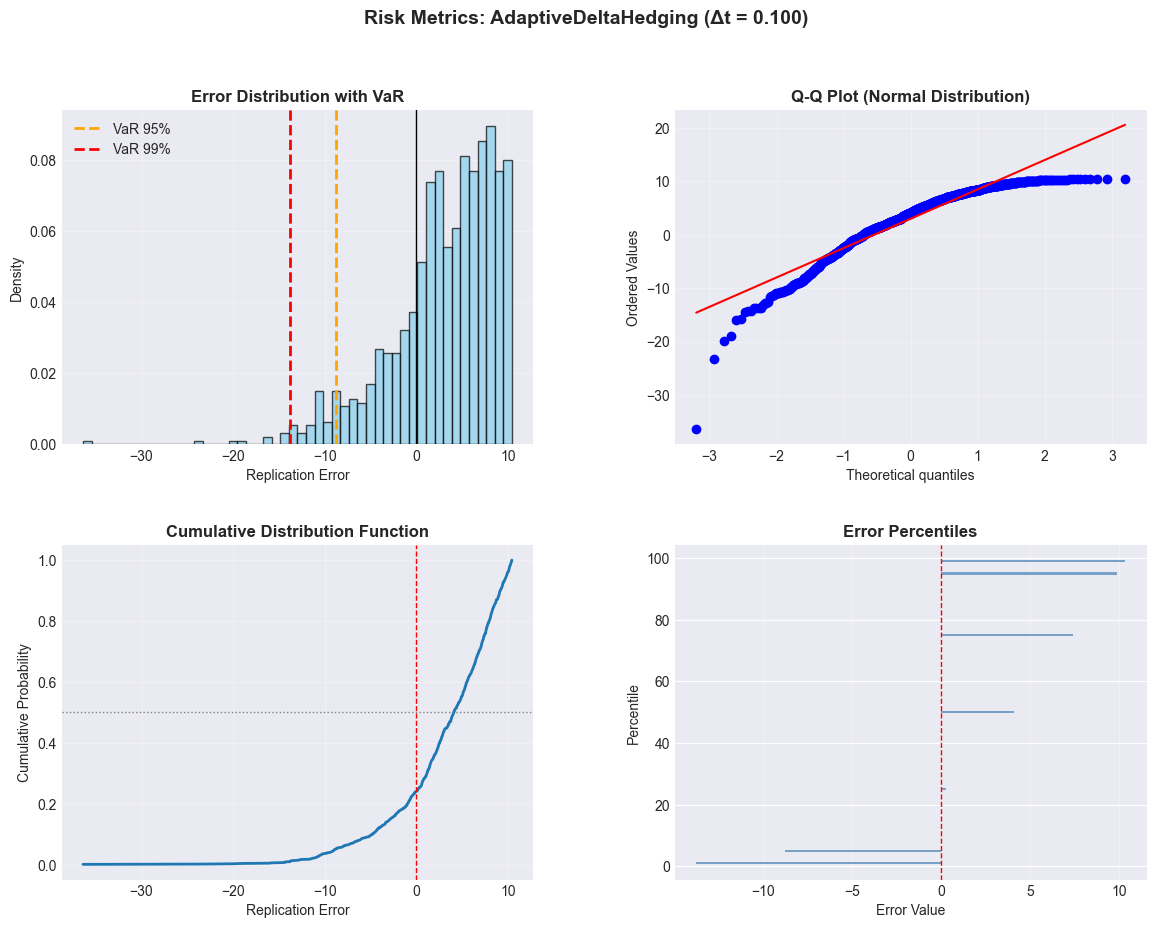


Risk Report: AdaptiveDeltaHedging (Δt = 0.100)
----------------------------------------------------------------------
  mean_error                    :     2.9837
  median_error                  :     4.0792
  std_error                     :     5.7605
  min_error                     :   -36.3930
  max_error                     :    10.4164
  percentile_1                  :   -13.7708
  percentile_5                  :    -8.8133
  percentile_25                 :     0.2734
  percentile_75                 :     7.3909
  percentile_95                 :     9.8574
  percentile_99                 :    10.3176
  var_90                        :    -4.7572
  var_95                        :    -8.8133
  var_99                        :   -13.7708
  cvar_90                       :    -9.5013
  cvar_95                       :   -12.3014
  cvar_99                       :   -18.7377
  prob_loss                     :     0.2400
  prob_loss_1pct                :     0.2400
  prob_loss_5pct          

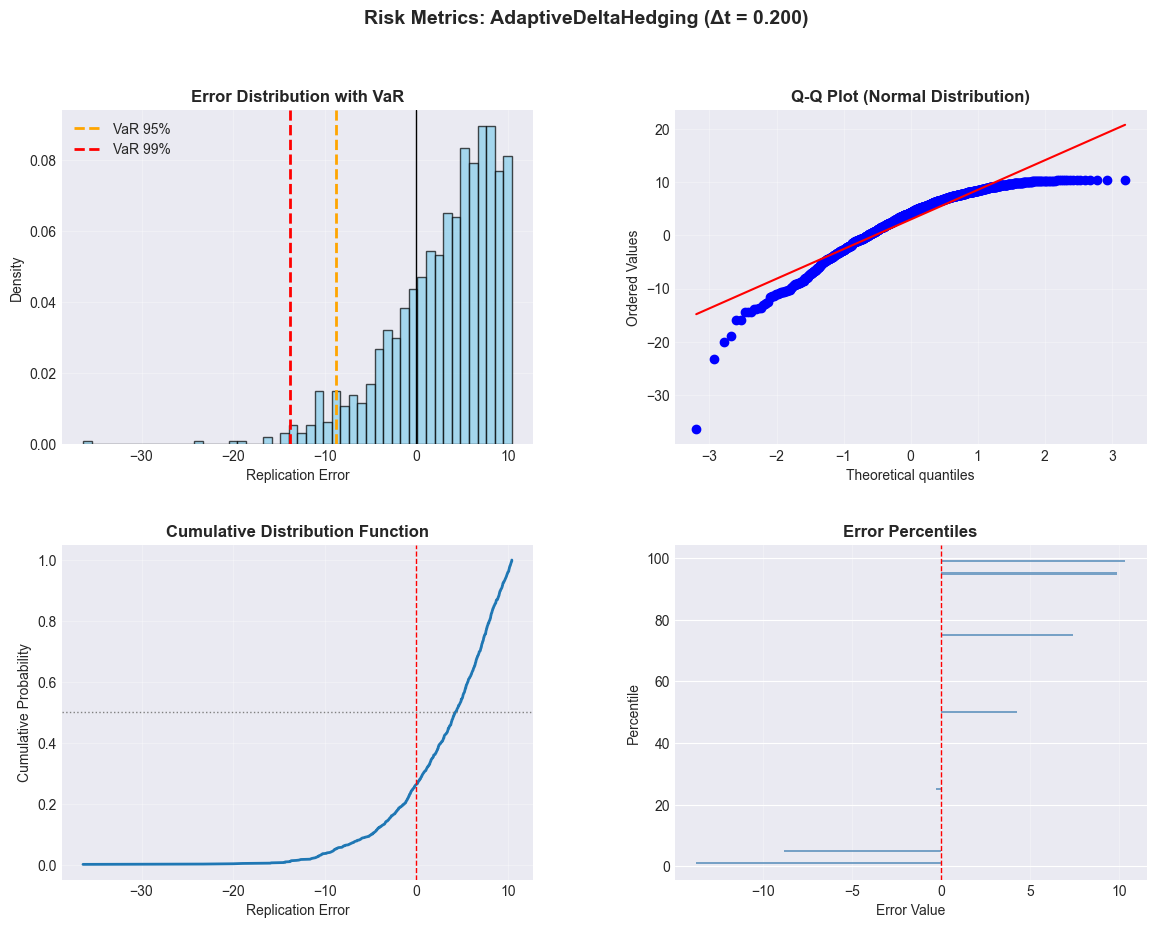


Risk Report: AdaptiveDeltaHedging (Δt = 0.200)
----------------------------------------------------------------------
  mean_error                    :     2.9589
  median_error                  :     4.2476
  std_error                     :     5.8211
  min_error                     :   -36.3930
  max_error                     :    10.4168
  percentile_1                  :   -13.7708
  percentile_5                  :    -8.8133
  percentile_25                 :    -0.3264
  percentile_75                 :     7.4059
  percentile_95                 :     9.8638
  percentile_99                 :    10.3207
  var_90                        :    -4.7697
  var_95                        :    -8.8133
  var_99                        :   -13.7708
  cvar_90                       :    -9.5245
  cvar_95                       :   -12.3014
  cvar_99                       :   -18.7377
  prob_loss                     :     0.2630
  prob_loss_1pct                :     0.2630
  prob_loss_5pct          

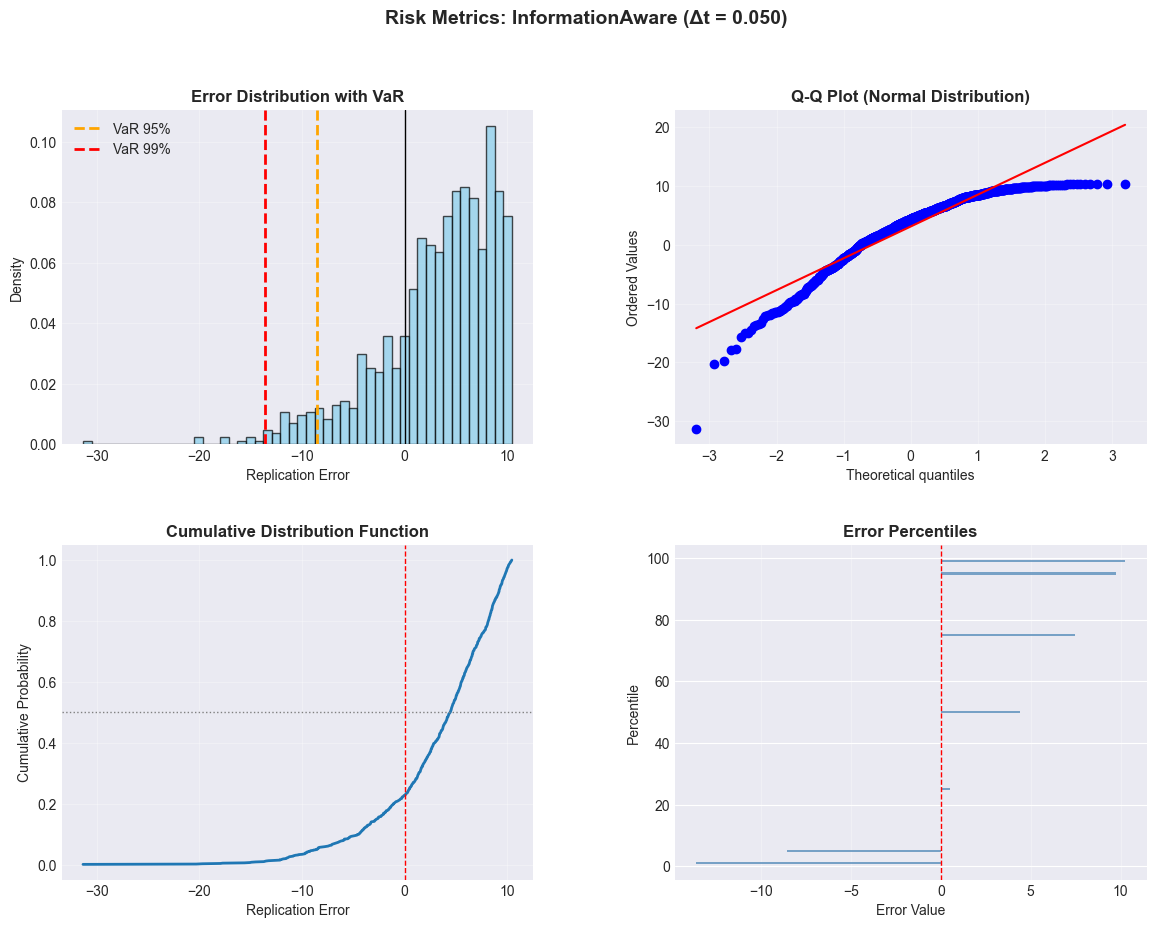


Risk Report: InformationAware (Δt = 0.050)
----------------------------------------------------------------------
  mean_error                    :     3.1227
  median_error                  :     4.4270
  std_error                     :     5.6737
  min_error                     :   -31.3333
  max_error                     :    10.4350
  percentile_1                  :   -13.6104
  percentile_5                  :    -8.5630
  percentile_25                 :     0.4833
  percentile_75                 :     7.4417
  percentile_95                 :     9.7555
  percentile_99                 :    10.2523
  var_90                        :    -4.4548
  var_95                        :    -8.5630
  var_99                        :   -13.6104
  cvar_90                       :    -9.2945
  cvar_95                       :   -12.1503
  cvar_99                       :   -18.0849
  prob_loss                     :     0.2270
  prob_loss_1pct                :     0.2270
  prob_loss_5pct              

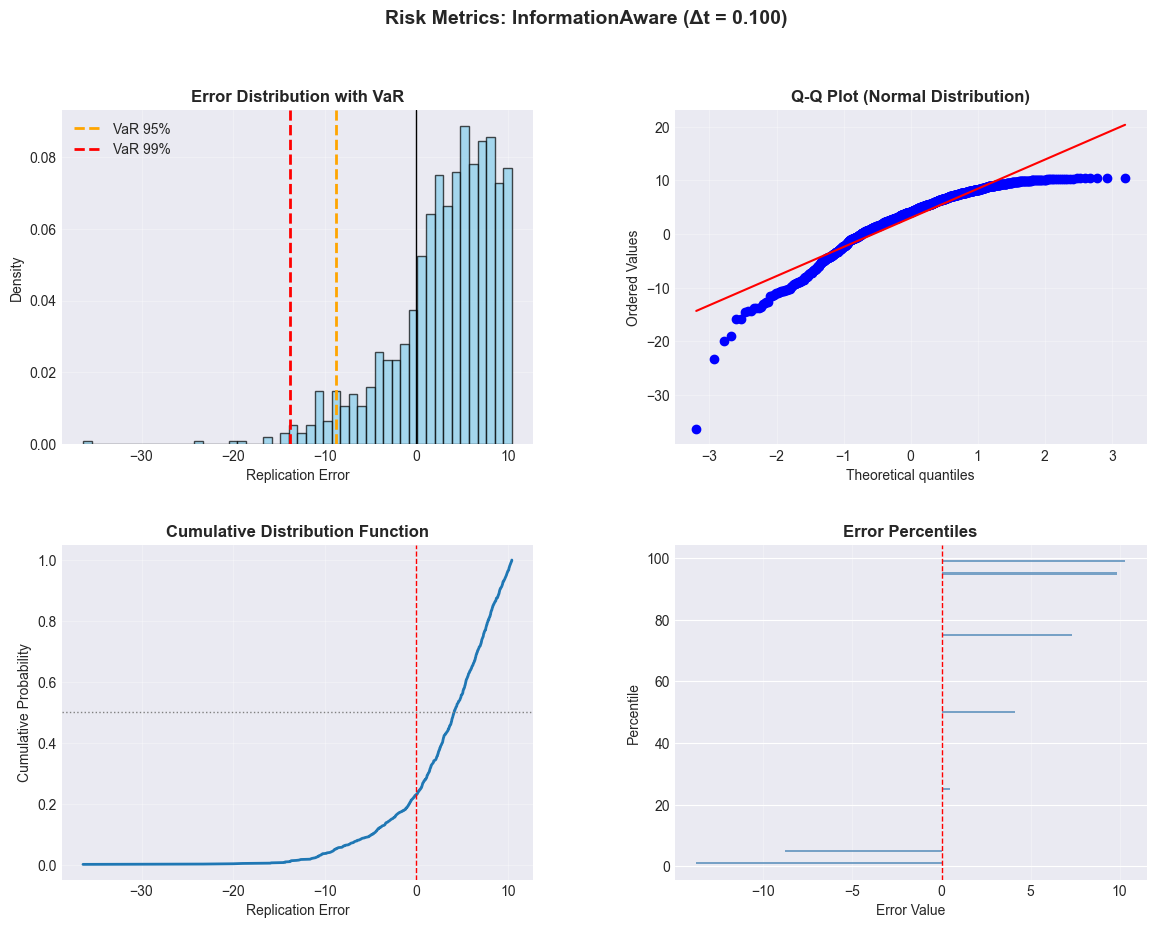


Risk Report: InformationAware (Δt = 0.100)
----------------------------------------------------------------------
  mean_error                    :     3.0170
  median_error                  :     4.1213
  std_error                     :     5.7050
  min_error                     :   -36.3930
  max_error                     :    10.4168
  percentile_1                  :   -13.7708
  percentile_5                  :    -8.8133
  percentile_25                 :     0.4919
  percentile_75                 :     7.3042
  percentile_95                 :     9.8332
  percentile_99                 :    10.3058
  var_90                        :    -4.7567
  var_95                        :    -8.8133
  var_99                        :   -13.7708
  cvar_90                       :    -9.5127
  cvar_95                       :   -12.3014
  cvar_99                       :   -18.7377
  prob_loss                     :     0.2290
  prob_loss_1pct                :     0.2290
  prob_loss_5pct              

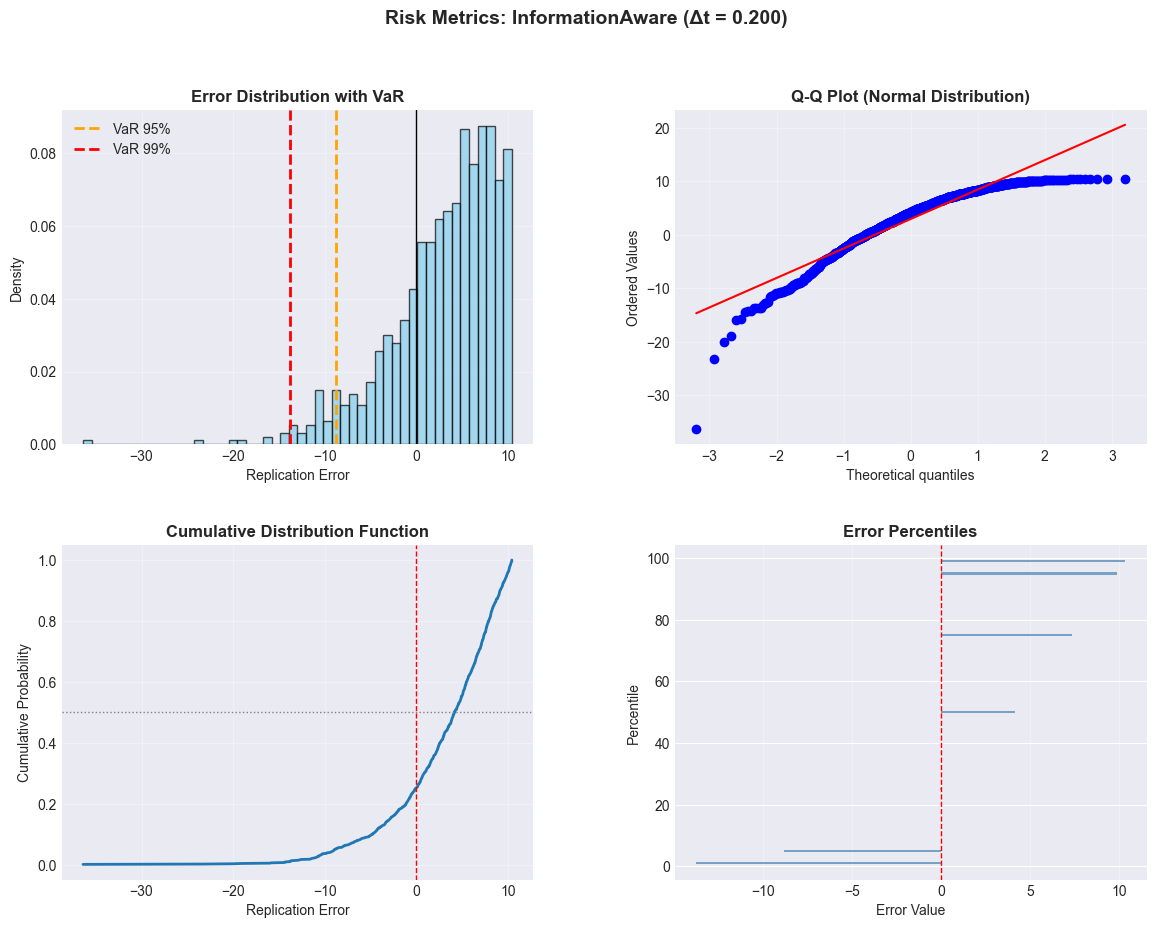


Risk Report: InformationAware (Δt = 0.200)
----------------------------------------------------------------------
  mean_error                    :     2.9477
  median_error                  :     4.1427
  std_error                     :     5.7765
  min_error                     :   -36.3930
  max_error                     :    10.4168
  percentile_1                  :   -13.7708
  percentile_5                  :    -8.8133
  percentile_25                 :    -0.0726
  percentile_75                 :     7.3387
  percentile_95                 :     9.8638
  percentile_99                 :    10.3207
  var_90                        :    -4.7572
  var_95                        :    -8.8133
  var_99                        :   -13.7708
  cvar_90                       :    -9.5113
  cvar_95                       :   -12.3014
  cvar_99                       :   -18.7377
  prob_loss                     :     0.2520
  prob_loss_1pct                :     0.2520
  prob_loss_5pct              

In [40]:
# Generate risk metrics for each agent and stopping interval
for agent_name in experiment1_results.keys():
    for interval in STOPPING_INTERVALS:
        errors = experiment1_results[agent_name][interval]['errors']
        
        fig = plot_risk_metrics_dashboard(errors)
        plt.suptitle(
            f"Risk Metrics: {agent_name} (Δt = {interval:.3f})", 
            fontsize=14, 
            fontweight='bold'
        )
        plt.tight_layout()
        plt.show()
        
        # Print risk report
        print(f"\nRisk Report: {agent_name} (Δt = {interval:.3f})")
        print("-" * 70)
        risk_report = generate_risk_report(errors)
        for key, value in risk_report.items():
            if isinstance(value, float):
                print(f"  {key:30s}: {value:>10.4f}")
            else:
                print(f"  {key:30s}: {value}")
        print()

### 8.2 Comprehensive Comparison Table

In [41]:
# Create comprehensive comparison table
print("="*100)
print("COMPREHENSIVE AGENT COMPARISON")
print("="*100)

comparison_data = []

for agent_name in experiment1_results.keys():
    for interval in STOPPING_INTERVALS:
        errors = experiment1_results[agent_name][interval]['errors']
        costs = experiment1_results[agent_name][interval]['costs']
        trades = experiment1_results[agent_name][interval]['trades']
        
        comparison_data.append({
            'Agent': agent_name,
            'Interval': f"{interval:.3f}",
            'Mean Error': np.mean(errors),
            'Std Error': np.std(errors),
            'VaR 95%': compute_var(errors, 0.95),
            'CVaR 95%': compute_cvar(errors, 0.95),
            'P(Loss)': compute_shortfall_probability(errors),
            'Mean Trades': np.mean(trades),
            'Mean Costs': np.mean(costs)
        })

# Print formatted table
print(f"{'Agent':<25s} {'Interval':<12s} {'Mean Error':<12s} {'Std Error':<12s} "
      f"{'VaR 95%':<12s} {'CVaR 95%':<12s} {'P(Loss)':<12s} {'Mean Trades':<12s}")
print("-"*100)

for row in comparison_data:
    print(f"{row['Agent']:<25s} {row['Interval']:<12s} "
          f"{row['Mean Error']:>12.4f} {row['Std Error']:>12.4f} "
          f"{row['VaR 95%']:>12.4f} {row['CVaR 95%']:>12.4f} "
          f"{row['P(Loss)']:>12.3f} {row['Mean Trades']:>12.1f}")

print("="*100)

COMPREHENSIVE AGENT COMPARISON
Agent                     Interval     Mean Error   Std Error    VaR 95%      CVaR 95%     P(Loss)      Mean Trades 
----------------------------------------------------------------------------------------------------
DeltaHedging              0.050              3.1342       5.7347      -8.5630     -12.1503        0.231          0.2
DeltaHedging              0.100              2.9837       5.7605      -8.8133     -12.3014        0.240          0.4
DeltaHedging              0.200              2.9589       5.8211      -8.8133     -12.3014        0.263          0.3
AdaptiveDeltaHedging      0.050              3.1342       5.7347      -8.5630     -12.1503        0.231          0.2
AdaptiveDeltaHedging      0.100              2.9837       5.7605      -8.8133     -12.3014        0.240          0.4
AdaptiveDeltaHedging      0.200              2.9589       5.8211      -8.8133     -12.3014        0.263          0.3
InformationAware          0.050              3.12

## 9. Agent Performance Comparison Visualization

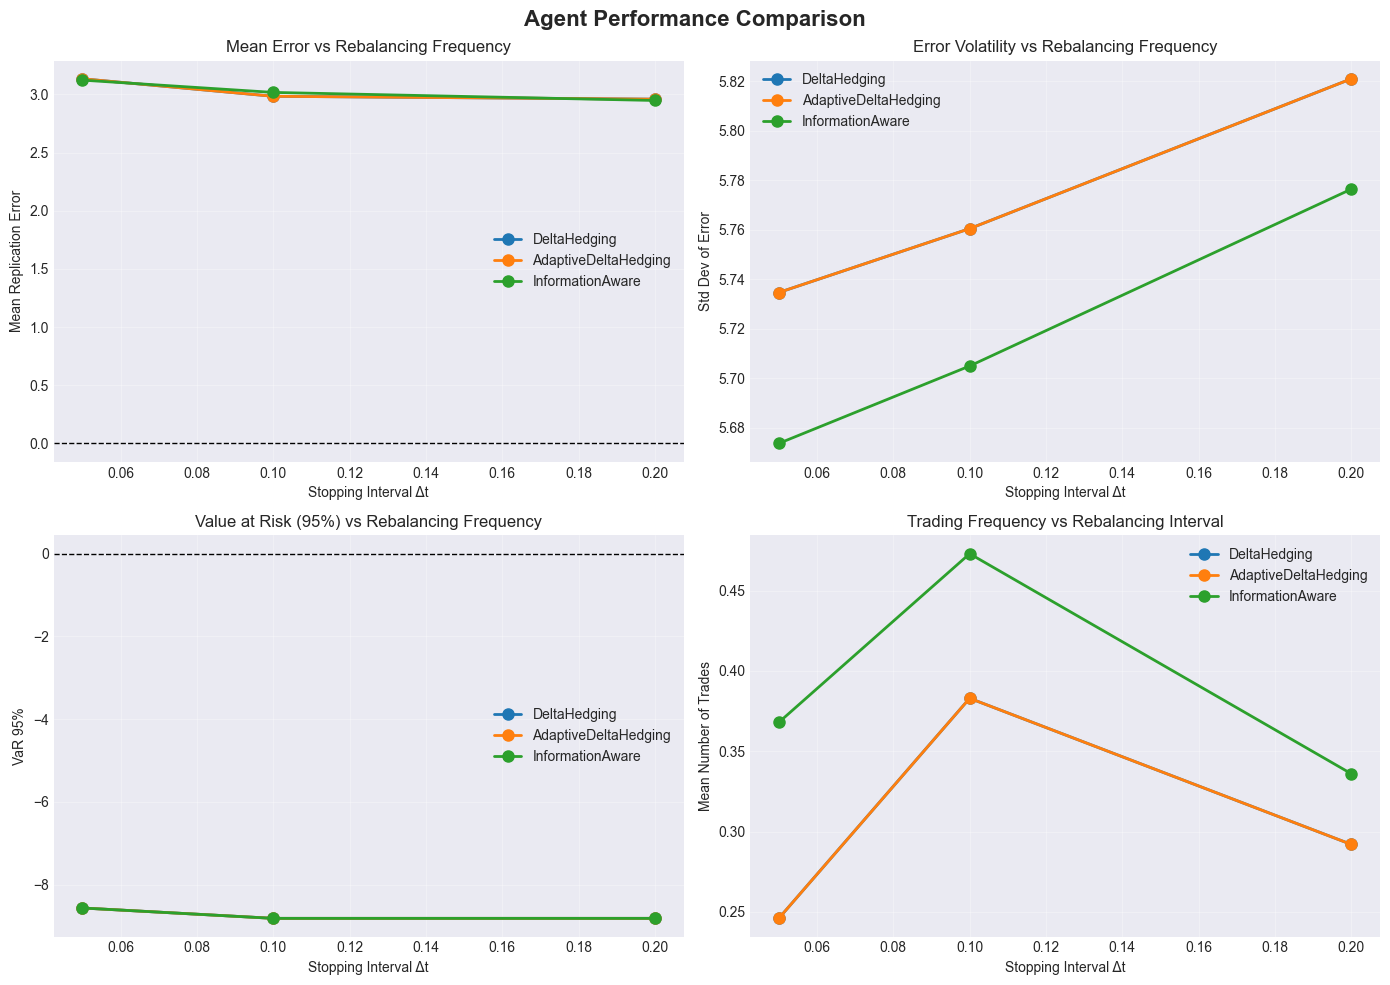

In [42]:
# Create side-by-side comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean Error Comparison
ax1 = axes[0, 0]
for agent_name in experiment1_results.keys():
    mean_errors = [np.mean(experiment1_results[agent_name][interval]['errors']) 
                   for interval in STOPPING_INTERVALS]
    ax1.plot(STOPPING_INTERVALS, mean_errors, 'o-', label=agent_name, linewidth=2, markersize=8)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Stopping Interval Δt')
ax1.set_ylabel('Mean Replication Error')
ax1.set_title('Mean Error vs Rebalancing Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Standard Deviation Comparison
ax2 = axes[0, 1]
for agent_name in experiment1_results.keys():
    std_errors = [np.std(experiment1_results[agent_name][interval]['errors']) 
                  for interval in STOPPING_INTERVALS]
    ax2.plot(STOPPING_INTERVALS, std_errors, 'o-', label=agent_name, linewidth=2, markersize=8)
ax2.set_xlabel('Stopping Interval Δt')
ax2.set_ylabel('Std Dev of Error')
ax2.set_title('Error Volatility vs Rebalancing Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. VaR Comparison
ax3 = axes[1, 0]
for agent_name in experiment1_results.keys():
    var_95 = [compute_var(experiment1_results[agent_name][interval]['errors'], 0.95) 
              for interval in STOPPING_INTERVALS]
    ax3.plot(STOPPING_INTERVALS, var_95, 'o-', label=agent_name, linewidth=2, markersize=8)
ax3.axhline(0, color='black', linestyle='--', linewidth=1)
ax3.set_xlabel('Stopping Interval Δt')
ax3.set_ylabel('VaR 95%')
ax3.set_title('Value at Risk (95%) vs Rebalancing Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Trade Count Comparison
ax4 = axes[1, 1]
for agent_name in experiment1_results.keys():
    mean_trades = [np.mean(experiment1_results[agent_name][interval]['trades']) 
                   for interval in STOPPING_INTERVALS]
    ax4.plot(STOPPING_INTERVALS, mean_trades, 'o-', label=agent_name, linewidth=2, markersize=8)
ax4.set_xlabel('Stopping Interval Δt')
ax4.set_ylabel('Mean Number of Trades')
ax4.set_title('Trading Frequency vs Rebalancing Interval')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Agent Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Key Inferences and Conclusions

In [43]:
print("="*70)
print("KEY INFERENCES AND CONCLUSIONS")
print("="*70)

# 1. Convergence Analysis
print("\n1. CONVERGENCE ANALYSIS:")
print("   - As Δt → 0, replication error should decrease")
print("   - Error variance should scale approximately as O(Δt)")
print("   - Mean error should be close to zero (unbiased hedging)")

for agent_name in experiment1_results.keys():
    errors_005 = experiment1_results[agent_name][0.05]['errors']
    errors_02 = experiment1_results[agent_name][0.2]['errors']
    
    var_ratio = np.var(errors_02) / np.var(errors_005)
    expected_ratio = 0.2 / 0.05  # 4x
    
    print(f"\n   {agent_name}:")
    print(f"     Variance ratio (0.2/0.05): {var_ratio:.2f} (expected ~{expected_ratio:.1f})")
    print(f"     Mean error (Δt=0.05): {np.mean(errors_005):.4f}")
    print(f"     Mean error (Δt=0.2):  {np.mean(errors_02):.4f}")

# 2. Agent Comparison
print("\n\n2. AGENT COMPARISON:")
print("   Comparing performance across all agents:")

for interval in STOPPING_INTERVALS:
    print(f"\n   Stopping Interval Δt = {interval:.3f}:")
    
    best_std = float('inf')
    best_agent = None
    
    for agent_name in experiment1_results.keys():
        errors = experiment1_results[agent_name][interval]['errors']
        std_err = np.std(errors)
        
        if std_err < best_std:
            best_std = std_err
            best_agent = agent_name
        
        print(f"     {agent_name:25s}: Std = {std_err:.4f}")
    
    print(f"     → Best: {best_agent} (lowest std dev)")

# 3. Transaction Cost Impact
print("\n\n3. TRANSACTION COST IMPACT:")
print("   - Higher costs reduce optimal rebalancing frequency")
print("   - Trade-off between hedging error and transaction costs")

for cost_bps in [0, 10, 50]:
    if cost_bps in experiment2_results:
        print(f"\n   Cost Rate: {cost_bps} bps")
        
        best_effective = float('inf')
        best_interval = None
        
        for interval in STOPPING_INTERVALS:
            errors = experiment2_results[cost_bps][interval]['errors']
            costs = experiment2_results[cost_bps][interval]['costs']
            effective = np.mean(errors) + np.mean(costs)
            
            if effective < best_effective:
                best_effective = effective
                best_interval = interval
            
            print(f"     Δt = {interval:.3f}: Effective Cost = {effective:.4f}")
        
        print(f"     → Optimal: Δt = {best_interval:.3f}")

# 4. Information-Aware Strategy Benefits
print("\n\n4. INFORMATION-AWARE STRATEGY:")
if 'InformationAware' in experiment1_results:
    print("   Comparing InformationAware vs DeltaHedging:")
    
    for interval in STOPPING_INTERVALS:
        info_errors = experiment1_results['InformationAware'][interval]['errors']
        naive_errors = experiment1_results['DeltaHedging'][interval]['errors']
        
        std_improvement = (np.std(naive_errors) - np.std(info_errors)) / np.std(naive_errors) * 100
        
        print(f"\n   Δt = {interval:.3f}:")
        print(f"     Std reduction: {std_improvement:.1f}%")
        print(f"     Naive std:    {np.std(naive_errors):.4f}")
        print(f"     Info std:     {np.std(info_errors):.4f}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

KEY INFERENCES AND CONCLUSIONS

1. CONVERGENCE ANALYSIS:
   - As Δt → 0, replication error should decrease
   - Error variance should scale approximately as O(Δt)
   - Mean error should be close to zero (unbiased hedging)

   DeltaHedging:
     Variance ratio (0.2/0.05): 1.03 (expected ~4.0)
     Mean error (Δt=0.05): 3.1342
     Mean error (Δt=0.2):  2.9589

   AdaptiveDeltaHedging:
     Variance ratio (0.2/0.05): 1.03 (expected ~4.0)
     Mean error (Δt=0.05): 3.1342
     Mean error (Δt=0.2):  2.9589

   InformationAware:
     Variance ratio (0.2/0.05): 1.04 (expected ~4.0)
     Mean error (Δt=0.05): 3.1227
     Mean error (Δt=0.2):  2.9477


2. AGENT COMPARISON:
   Comparing performance across all agents:

   Stopping Interval Δt = 0.050:
     DeltaHedging             : Std = 5.7347
     AdaptiveDeltaHedging     : Std = 5.7347
     InformationAware         : Std = 5.6737
     → Best: InformationAware (lowest std dev)

   Stopping Interval Δt = 0.100:
     DeltaHedging             : 

## 11. Summary Statistics

In [44]:
# Create summary statistics table
import pandas as pd

summary_rows = []

for agent_name in experiment1_results.keys():
    for interval in STOPPING_INTERVALS:
        errors = experiment1_results[agent_name][interval]['errors']
        costs = experiment1_results[agent_name][interval]['costs']
        trades = experiment1_results[agent_name][interval]['trades']
        
        summary_rows.append({
            'Agent': agent_name,
            'Interval': interval,
            'Mean Error': np.mean(errors),
            'Std Error': np.std(errors),
            'Median Error': np.median(errors),
            'VaR 95%': compute_var(errors, 0.95),
            'CVaR 95%': compute_cvar(errors, 0.95),
            'P(Loss)': compute_shortfall_probability(errors),
            'Mean Trades': np.mean(trades),
            'Mean Costs': np.mean(costs)
        })

df_summary = pd.DataFrame(summary_rows)
print("Summary Statistics:")
print("="*100)
print(df_summary.to_string(index=False))
print("="*100)

Summary Statistics:
               Agent  Interval  Mean Error  Std Error  Median Error   VaR 95%   CVaR 95%  P(Loss)  Mean Trades  Mean Costs
        DeltaHedging      0.05    3.134181   5.734687      4.479130 -8.562955 -12.150349    0.231        0.246         0.0
        DeltaHedging      0.10    2.983707   5.760499      4.079216 -8.813348 -12.301433    0.240        0.383         0.0
        DeltaHedging      0.20    2.958933   5.821065      4.247585 -8.813348 -12.301433    0.263        0.292         0.0
AdaptiveDeltaHedging      0.05    3.134181   5.734687      4.479130 -8.562955 -12.150349    0.231        0.246         0.0
AdaptiveDeltaHedging      0.10    2.983707   5.760499      4.079216 -8.813348 -12.301433    0.240        0.383         0.0
AdaptiveDeltaHedging      0.20    2.958933   5.821065      4.247585 -8.813348 -12.301433    0.263        0.292         0.0
    InformationAware      0.05    3.122663   5.673700      4.427041 -8.562955 -12.150349    0.227        0.368         